# Improving earthquake metadata for GNSS time series analysis using Okada-based co-seismic deformation modelling
# ***Point Source Model***
*** 
***

## **0. Workflow**

This notebook uses the Point Source section of the Okada 1985 model [1] for surface deformations resulting from shear and tensile internal dislocations. The workflow is as follows:

1. Locate all Nevada Geodetic Laboratory (NGL) Stations in Greece.
2. From the Global CMT solution from 2000 to 2020, retrieve the data of the 10 largest earthquakes in Greece.
3. Write the Okada 1985 [1] point-source deformation code and verify it with the calibration table that Okada provided.
4. Refine the code to apply to real-life earthquakes from the Global CMT solution.
5. Compute the surface deformations at all relevant NGL stations from the 10 largest earthquakes in Greece.

*** 

[1] Y. Okada, “Surface deformation due to shear and tensile faults in a half-space,” Bulletin of the Seismological Society of America, vol. 75, no. 4, pp. 1135–1154, Aug. 1985. doi:10.1785/bssa0750041135

## **1. Locate all Nevada Geodetic Laboratory (NGL) Stations in Greece.**

### 1.1. Downloading Greek Stations.

The Eurasian plate stations connected to the NGL network are all listed in *https://geodesy.unr.edu/gps_timeseries/IGS20/midas/midas.EU.txt*. The file that explains the metadata of each stations is given in *https://geodesy.unr.edu/velocities/midas.readme.txt*.

As we extract data from the NGL database, note that we only need the Station_ID, the Latitude, and the Longitude of the station. The altitude is not relevant for Okada's model, since it assumes a homogeneous, isotropic elastic half-space, wherein the observation point is exactly on the flat surface $z=0$.

The discrepancy of local topography to an ideal flat surface is one source of error. Another source is the ellipsoidal form of the Earth, which can only be approximated as flat for around $10 km$. This code will use distances up to $500 km$, depending on the magnitude of the earthquake. We will observe how this affects the results.

In [1]:
import pandas as pd

In [2]:
url = "https://geodesy.unr.edu/velocities/midas.EU.txt"

df = pd.read_csv(url, sep=r'\s+', header=None)

parsed_df = pd.DataFrame({
        'Station_ID': df.iloc[:, 0].astype(str).str.upper(),
        'Latitude':    pd.to_numeric(df.iloc[:, 24], errors='coerce'),  # col 25
        'Longitude':   pd.to_numeric(df.iloc[:, 25], errors='coerce'),  # col 26
    })

The NGL network maps global stations continuously westward from the Prime Meridian, which makes the longitude mapping onvention span from $0^\circ$ to $-360^\circ$. To avoid confusion with Python packages such as cartopy, we must convert it to $-180^\circ$ to $180^\circ$, wherein $0^\circ$ is the Prime Meridian.

In [3]:
parsed_df.loc[parsed_df['Longitude'] < -180, 'Longitude'] += 360.0
parsed_df = parsed_df.dropna(subset=['Latitude', 'Longitude'])

The geographic boundaries of Greece are around $34^\circ N$ to $42^\circ N$ in latitude, and $19^\circ E$ to $29^\circ E$ in longitude. Applying this:

In [4]:
greece_df = parsed_df[
        (parsed_df['Latitude'].between(34.0, 42.0)) & 
        (parsed_df['Longitude'].between(19.0, 29.0))
    ].copy()

Finally, we save these to *.csv*. This should give us $270$ stations.

In [5]:
greece_df.to_csv("NGL_Greece_Stations.csv", index=False)
print(len(greece_df['Station_ID']))

270


### 1.2. Mapping Greek Stations.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

/home/ubuntu_user/miniconda3/envs/OCM_packs/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [7]:
df = pd.read_csv("NGL_Greece_Stations.csv", sep=",")
df["lat"] = pd.to_numeric(df["Latitude"], errors="coerce")
df["lon"] = pd.to_numeric(df["Longitude"], errors="coerce")
df = df.dropna(subset=["lat", "lon"])

Now we must create the map.

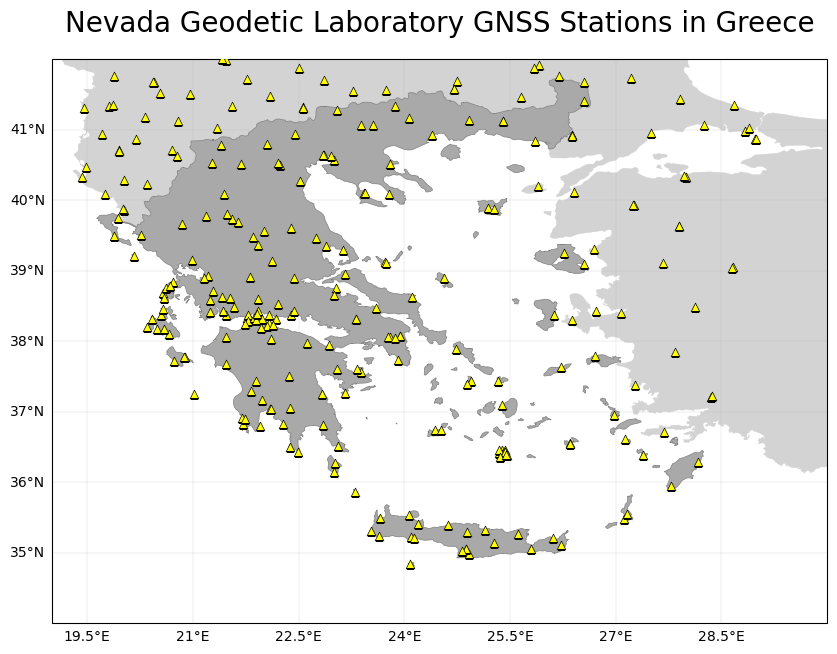

In [8]:
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([19, 30, 34, 42], crs=ccrs.PlateCarree()) # add boundary
ax.add_feature(cfeature.OCEAN, facecolor="white") # add ocean

# Download Natural Earth Country shapefiles
shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
countries = reader.records()

# Loop through countries and color them conditionally
for country in countries:
    name = country.attributes['SOVEREIGNT']
    if name == 'Greece':
        # Add Greece
        ax.add_geometries([country.geometry], ccrs.PlateCarree(),
                          facecolor='darkgray', edgecolor='gray', linewidth=0.5, zorder=2)
    else:
        # Add surrounding countries with a neutral background color
        ax.add_geometries([country.geometry], ccrs.PlateCarree(),
                          facecolor='lightgray', edgecolor='lightgray', linewidth=0.3, zorder=1)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, zorder=3)
gl.top_labels = False
gl.right_labels = False

# Plot NGL Stations
sc = ax.scatter(
    df["lon"], df["lat"], color="yellow", marker="^", #triangles
    s=40, alpha=1, edgecolor="k", zorder=5, #triangles brought to front
    linewidth=0.5, transform=ccrs.PlateCarree()
)

plt.title("Nevada Geodetic Laboratory GNSS Stations in Greece", size=20, pad=20)
plt.savefig("Greece_NGL_Stations_Map.png", bbox_inches='tight', dpi=300)
plt.show()

## **2. From the Global CMT solution from 1976 to 2026, retrieve the data of the 10 largest earthquakes in Greece.**

### 2.1. Downloading Greek Seismicity

The Global Centroid Moment Tensor solutions [2,3] completely define an earthquake due to a shear dislocation using a point-source approximation.

The .ndk file of CMT solutions from 1976 to 2020 can be downloaded from *https://www.globalcmt.org/CMTfiles.html*.

There should be exactly $56,832$ earthquakes in *jan76_dec20.ndk*.

We will be extracting only events from 2000 to 2020.

***

[2] A. M. Dziewonski, T.-A. Chou, and J. H. Woodhouse, “Determination of earthquake source parameters from waveform data for studies of global and regional seismicity,” Journal of Geophysical Research, vol. 86, pp. 2825–2852, 1981, doi: 10.1029/JB086iB04p02825.

[3] G. Ekström, M. Nettles, and A. M. Dziewonski, “The global CMT project 2004–2010: Centroid-moment tensors for 13,017 earthquakes,” Physics of the Earth and Planetary Interiors, vols. 200–201, pp. 1–9, 2012, doi: 10.1016/j.pepi.2012.04.002.

In [9]:
from obspy import read_events
from obspy import UTCDateTime

In [10]:
cmt_catalog = read_events("jan76_dec20.ndk")
print(len(cmt_catalog))

56832


Recall that the Okada 1985 model uses a planar approximation. Thus for simplicity, we must only include earthquakes in the vicinity of Greece. The remaining events should be 476.

In [11]:
start_time = UTCDateTime("2000-01-01T00:00:00")
end_time   = UTCDateTime("2020-12-31T23:59:59")

greece_catalog = cmt_catalog.filter(
    "time >= %s" % start_time,
    "time <= %s" % end_time,
    "latitude >= 34",
    "latitude <= 42",
    "longitude >= 19",
    "longitude <= 29"
)

greece_catalog.write("Greece_Seismicity.xml", format="QUAKEML")
print(len(greece_catalog))

476


### 2.2. Mapping Greek Seismicity

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

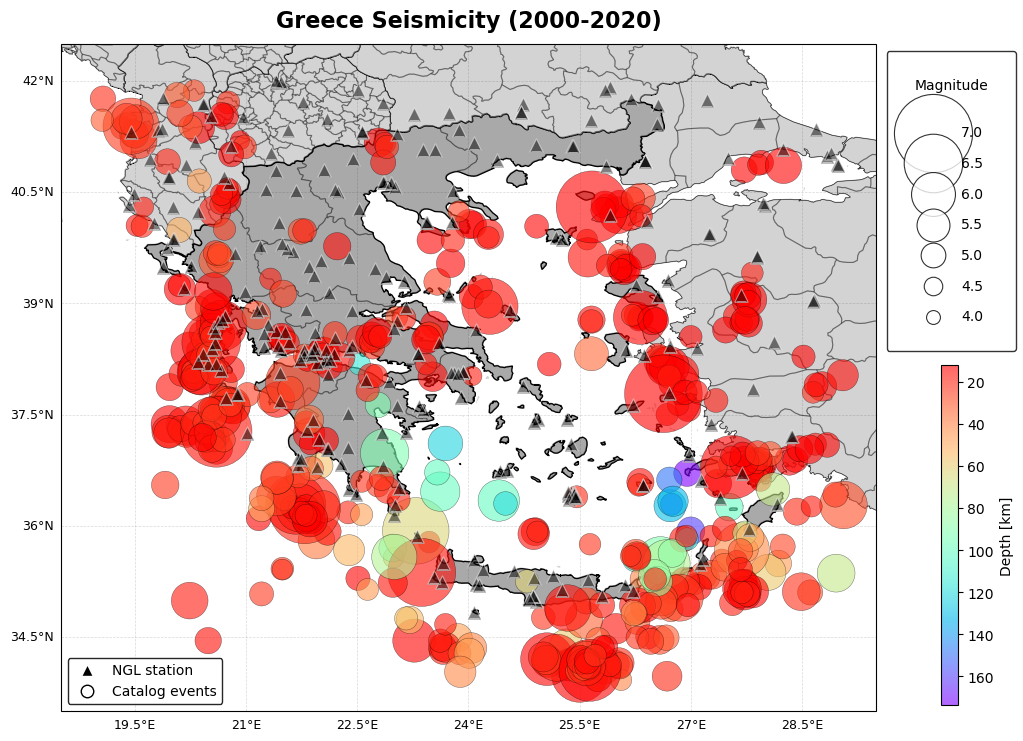

In [36]:
# Loading Station Data
df = pd.read_csv("NGL_Greece_Stations.csv", sep=",")
df["sta_lats"] = pd.to_numeric(df["Latitude"], errors="coerce")
df["sta_lons"] = pd.to_numeric(df["Longitude"], errors="coerce")
df = df.dropna(subset=["sta_lats", "sta_lons"])

# Catalog Data
ev_lons, ev_lats, ev_mags, ev_deps = [], [], [], []
for ev in greece_catalog:
    # Safely get the preferred origin and magnitude, or fallback to the first one
    origin = ev.preferred_origin() or ev.origins[0]
    mag = ev.preferred_magnitude() or ev.magnitudes[0]
    ev_lons.append(origin.longitude)
    ev_lats.append(origin.latitude)
    ev_mags.append(mag.mag)
    ev_deps.append(origin.depth / 1000.0 if origin.depth is not None else np.nan)  # m -> km

# Map Boundaries
lon_min, lon_max = 18.5, 29.5
lat_min, lat_max = 33.5, 42.5
fig = plt.figure(figsize=(11, 10), facecolor="white")
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Highlighting Greece using Natural Earth Country Shapefile
shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
countries = reader.records()
for country in countries:
    name = country.attributes['SOVEREIGNT']
    if name == 'Greece':
        # Add Greece with your custom color
        ax.add_geometries([country.geometry], ccrs.PlateCarree(),
                          facecolor='darkgray', edgecolor='black', linewidth=0.9) #"orchid"
    else:
        # Add surrounding countries with a neutral background color
        ax.add_geometries([country.geometry], ccrs.PlateCarree(),
                          facecolor='lightgray', edgecolor='black', linewidth=0.3) #"powderblue"

# Adding Features
ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="lightgrey", edgecolor="none")
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white", edgecolor="none")
ax.add_feature(cfeature.STATES.with_scale("10m"), linewidth=0.8, edgecolor="black", facecolor="none", alpha=0.3)

# Gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="black",
    alpha=0.15, linestyle="--",
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"color": "black", "fontsize": 9}
gl.ylabel_style = {"color": "black", "fontsize": 9}
outline = [pe.withStroke(linewidth=2.5, foreground="black")]

# Plot Station Markers
ax.scatter(
    df["sta_lons"], df["sta_lats"], transform=ccrs.PlateCarree(),
    s=90, marker="^", color="black", edgecolors="white", linewidths=0.8,
    zorder=5, label="Seismic station", alpha=0.5
)

# Plot Catalog Events
# Scale circle size exponentially by magnitude for better visual hierarchy
sizes = [10 ** (float(m)/2)  for m in ev_mags] 
sc = ax.scatter(
    ev_lons, ev_lats, transform=ccrs.PlateCarree(),
    c=ev_deps, s=sizes, marker="o", cmap="rainbow_r",
    alpha=0.6, zorder=4, label="Catalog events",
    edgecolor="k", linewidth=0.3
)
cbar = plt.colorbar(sc, ax=ax, label="Depth [km]", shrink=0.35, anchor=(0.1, 0.25))
cbar.ax.invert_yaxis()

# Magnitude Size Legend
legend_mags = [7.0, 6.5, 6.0, 5.5, 5.0, 4.5, 4.0]  
#legend_mags = [4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0]  
legend_handles = []
for mag in legend_mags:
    legend_size = 10 ** (mag / 2) 
    handle = ax.scatter(
        [], [], s=legend_size, color="white", edgecolor="black", 
        linewidth=0.8, alpha=0.8, marker="o", label=f"{mag}"
    )
    legend_handles.append(handle)
mag_legend = ax.legend( # Plotting Legend
    bbox_to_anchor=(1.18, 1.0),
    handles=legend_handles, title="Magnitude\n", 
    frameon=True, facecolor="white", edgecolor="black", scatterpoints=1,
    labelspacing=1.2,   # vertical spacing
    borderpad=2.0,      # padding between legend and border
    handletextpad=1.0,# spacing between legend and text
) # scatterpoints=1 ensures only a single circle shows up per label text
ax.add_artist(mag_legend) #keeps the colorbar and the new legend separated


# Station and Event Legend
legend_elements = [
    Line2D(
        [0], [0], marker='^', color='w', label='NGL station',
        markerfacecolor='black', markeredgecolor='white', markersize=9
    ),
    Line2D(
        [0], [0], marker='o', color='w', label='Catalog events',
        markerfacecolor='white', markeredgecolor='black', markersize=9
    )
]

legend = ax.legend(
    handles=legend_elements, loc="lower left", framealpha=0.85,
    frameon=True, fontsize=10, facecolor="white", edgecolor="black"
)

# Title
ax.set_title(
    "Greece Seismicity (2000-2020)",
    fontsize=16, fontweight="bold", color="black", pad=12,
)
ax.set_facecolor("white")
plt.tight_layout()
plt.savefig("Greece_Seismicity_2000-2020.png", dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### 2.3. Isolating 10 largest Earthquakes

In [20]:
from obspy import read_events
import pandas as pd

In [21]:
# Read data into list
event_list = []
for event in greece_catalog:
    magnitude = event.preferred_magnitude() or event.magnitudes[0]       
    event_list.append({
        'mag':       magnitude.mag
    })

In [22]:
# Sort and Slice List to get Largest 10 Earthquakes
data = pd.DataFrame(event_list)
sorted_data = data.sort_values(by='mag', ascending=False).reset_index(drop=True)
big10_eqs = sorted_data[:10]
print(big10_eqs)

    mag
0  6.99
1  6.86
2  6.85
3  6.84
4  6.76
5  6.72
6  6.64
7  6.60
8  6.54
9  6.50


In [23]:
big10_catalog = greece_catalog.filter("magnitude >= 6.5")
big10_catalog.write("Big10_Greece_Seismicity.xml", format="QUAKEML")
print(len(big10_catalog))

10


### 2.4. Mapping 10 largest Earthquakes

In [24]:
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

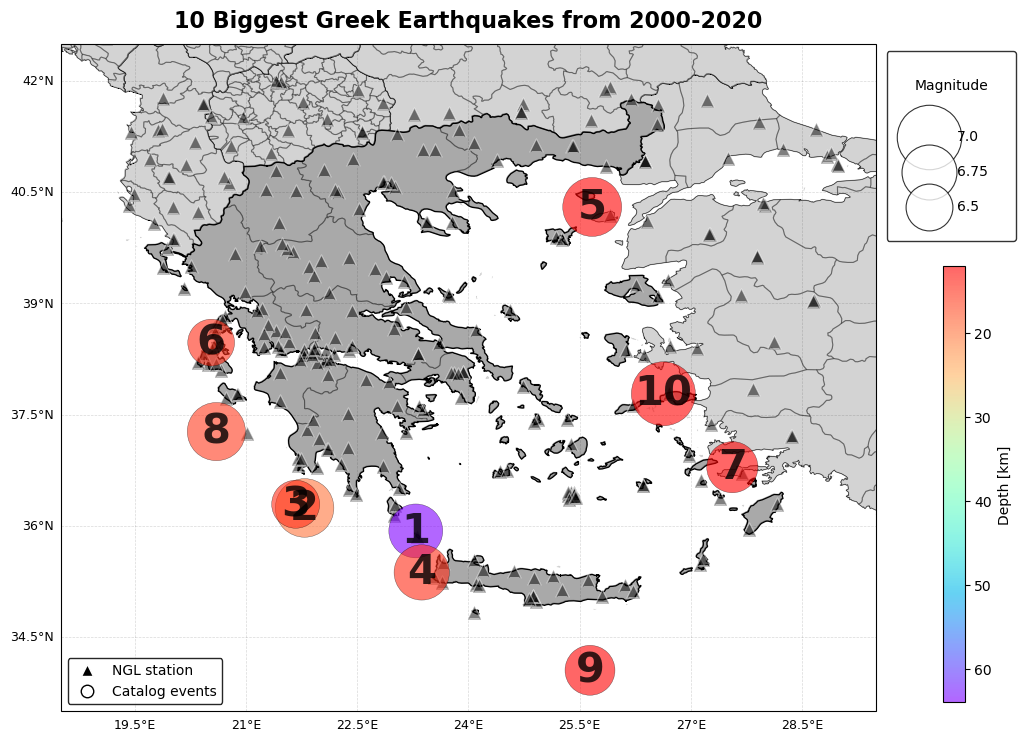

In [35]:
# Loading Station Data
df = pd.read_csv("NGL_Greece_Stations.csv", sep=",")
df["sta_lats"] = pd.to_numeric(df["Latitude"], errors="coerce")
df["sta_lons"] = pd.to_numeric(df["Longitude"], errors="coerce")
df = df.dropna(subset=["sta_lats", "sta_lons"])

# Catalog Data
ev_lons, ev_lats, ev_mags, ev_deps = [], [], [], []
for ev in big10_catalog:
    # Safely get the preferred origin and magnitude, or fallback to the first one
    origin = ev.preferred_origin() or ev.origins[0]
    mag = ev.preferred_magnitude() or ev.magnitudes[0]
    ev_lons.append(origin.longitude)
    ev_lats.append(origin.latitude)
    ev_mags.append(mag.mag)
    ev_deps.append(origin.depth / 1000.0 if origin.depth is not None else np.nan)  # m -> km

# Map Boundaries
lon_min, lon_max = 18.5, 29.5
lat_min, lat_max = 33.5, 42.5
fig = plt.figure(figsize=(11, 10), facecolor="white")
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Highlighting Greece using Natural Earth Country Shapefile
shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
countries = reader.records()
for country in countries:
    name = country.attributes['SOVEREIGNT']
    if name == 'Greece':
        # Add Greece with your custom color
        ax.add_geometries([country.geometry], ccrs.PlateCarree(),
                          facecolor='darkgray', edgecolor='black', linewidth=0.9, zorder=2) #"orchid"
    else:
        # Add surrounding countries with a neutral background color
        ax.add_geometries([country.geometry], ccrs.PlateCarree(),
                          facecolor='lightgray', edgecolor='black', linewidth=0.3, zorder=1) #"powderblue"

# Adding Features
ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="lightgrey", edgecolor="none")
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white", edgecolor="none")
ax.add_feature(cfeature.STATES.with_scale("10m"), linewidth=0.8, edgecolor="black",
               facecolor="none", alpha=0.3, zorder=3)

# Gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="black",
    alpha=0.15, linestyle="--",
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"color": "black", "fontsize": 9}
gl.ylabel_style = {"color": "black", "fontsize": 9}
outline = [pe.withStroke(linewidth=2.5, foreground="black")]

# Plot Station Markers
ax.scatter(
    df["sta_lons"], df["sta_lats"], transform=ccrs.PlateCarree(),
    s=90, marker="^", color="black", edgecolors="white", linewidths=0.8,
    label="Seismic station", alpha=0.5, zorder=4
)

# Plot Catalog Events
# Scale circle size exponentially by magnitude for better visual hierarchy
sizes = [10 ** (float(m-1)/1.8)  for m in ev_mags] 
sc = ax.scatter(
    ev_lons, ev_lats, transform=ccrs.PlateCarree(),
    c=ev_deps, s=sizes, marker="o", cmap="rainbow_r",
    alpha=0.6, label="Catalog events", zorder=5,
    edgecolor="k", linewidth=0.3
)
cbar = plt.colorbar(sc, ax=ax, label="Depth [km]", shrink=0.45, anchor=(0.12, 0.3))
cbar.ax.invert_yaxis()

# Magnitude Size Legend
legend_mags = [7.0, 6.75, 6.5]
legend_handles = []
for mag in legend_mags:
    legend_size = 10 ** ((mag-1)/1.8) 
    handle = ax.scatter(
        [], [], s=legend_size, color="white", edgecolor="black", 
        linewidth=0.8, alpha=0.8, marker="o", label=f"{mag}"
    )
    legend_handles.append(handle)
mag_legend = ax.legend( # Plotting Legend
    bbox_to_anchor=(1.18, 1.0),
    handles=legend_handles, title="Magnitude\n", 
    frameon=True, facecolor="white", edgecolor="black", scatterpoints=1,
    labelspacing=1.5,   # vertical spacing
    borderpad=2.0,      # padding between legend and border
    handletextpad=1.0,# spacing between legend and text
) # scatterpoints=1 ensures only a single circle shows up per label text
ax.add_artist(mag_legend) #keeps the colorbar and the new legend separated


# Station and Event Legend
legend_elements = [
    Line2D(
        [0], [0], marker='^', color='w', label='NGL station',
        markerfacecolor='black', markeredgecolor='white', markersize=9
    ),
    Line2D(
        [0], [0], marker='o', color='w', label='Catalog events',
        markerfacecolor='white', markeredgecolor='black', markersize=9
    )
]

legend = ax.legend(
    handles=legend_elements, loc="lower left", framealpha=0.85,
    frameon=True, fontsize=10, facecolor="white", edgecolor="black"
)

# Labelling Earthquakes
for i in range(0,10):
    plt.text(ev_lons[i], ev_lats[i], str(i+1), ha="center",
             va="center", fontsize=30, alpha=0.8,
             zorder=6, color="black", weight="bold")

# Title
ax.set_title(
    "10 Biggest Greek Earthquakes from 2000-2020",
    fontsize=16, fontweight="bold", color="black", pad=12,
)
ax.set_facecolor("white")
plt.tight_layout()
plt.savefig("Big10_Greece_Seismicity_2000-2020.png", dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## **3. Write the Okada 1985 point-source deformation code and verify it with the calibration table that Okada provided.**

In [20]:
import numpy as np

The displacement field $u_i(x_1,x_2,x_3)$ due to a dislocation $\Delta u_j(\xi_1.\xi_2,\xi_3)$ across an internal surface $\Sigma$ in an isotropic medium is given by:

\begin{equation}
u_i=\frac{1}{F}\int\int_\Sigma\Delta u_j\biggr[\lambda\delta_{jk}\frac{\partial u_i^j}{\partial\xi_k}+\mu\biggr(\frac{\partial u_i^j}{\partial\xi_k}+\frac{\partial u_i^k}{\partial\xi_j}\biggr)\biggr]\nu_kd\Sigma \tag{1}
\end{equation}

where $\delta_{jk}$ is the Kronecker delta, $\lambda$ and $\mu$ are Lame parameters, $\nu_k$ is the direction cosine of the normal to the surface element $d\Sigma$, and the summation convention applies. $u_i^j$ is the $i$th component of the displacement at $(x_1,x_2,x_3)$ due to the $j$th direction point force of magnitude $F$ at $(\xi_1,\xi_2\xi_3)$ [4].

Okada [1] provides a compact solution for this.

***

[4] J. A. Steketee, “Some geophysical applications of the elasticity theory of dislocations,” Can. J. Phys., vol. 36, no. 9, pp. 1168–1197, Sep. 1958. [Online]. Available: Canadian Science Publishing

### 3.1. Translation into Okada's Coordinate System

In [22]:
def coords_sim (stalon, stalat, evlon, evlat, evdep, strike, dip, rake, opening, U):
    delsigma=1.0
    dEast = stalon - evlon
    dNorth = stalat - evlat
    return(
        delsigma, #delsigma
        U*np.cos(rake*np.pi/180.0), #U1
        U*np.sin(rake*np.pi/180.0), #U2
        opening, #m #U3
        dEast * np.sin(strike*np.pi/180.0) + dNorth * np.cos(strike*np.pi/180.0), #x
        -dEast * np.cos(strike*np.pi/180.0) + dNorth * np.sin(strike*np.pi/180.0), #y
        abs(evdep), #d
        30.0, #GPa #mu
        30.0, #GPa #lam
        dip*np.pi/180.0 #in radians #delta
    )

### 3.2. Displacements

For Strike-Slip:
\begin{cases}
u_x^0=-\frac{U_1}{2\pi}\biggr[\frac{3x^2q}{R^5}+I_1^0\sin\delta\biggr]\Delta\Sigma \\
u_y^0=-\frac{U_1}{2\pi}\biggr[\frac{3xyq}{R^5}+I_2^0\sin\delta\biggr]\Delta\Sigma \\
u_z^0=-\frac{U_1}{2\pi}\biggr[\frac{3xdq}{R^5}+I_4^0\sin\delta\biggr]\Delta\Sigma \\
\tag{2}
\end{cases}

For Dip-Slip:
\begin{cases}
u_x^0=-\frac{U_2}{2\pi}\biggr[\frac{3xpq}{R^5}-I_3^0\sin\delta\cos\delta\biggr]\Delta\Sigma \\
u_y^0=-\frac{U_2}{2\pi}\biggr[\frac{3ypq}{R^5}-I_1^0\sin\delta\cos\delta\biggr]\Delta\Sigma \\
u_z^0=-\frac{U_2}{2\pi}\biggr[\frac{3dpq}{R^5}-I_5^0\sin\delta\cos\delta\biggr]\Delta\Sigma \\
\tag{3}
\end{cases}

For Tensile Fault:
\begin{cases}
u_x^0=\frac{U_3}{2\pi}\biggr[\frac{3xq^2}{R^5}-I_3^0\sin^2\delta\biggr]\Delta\Sigma \\
u_y^0=\frac{U_3}{2\pi}\biggr[\frac{3y^2q}{R^5}-I_1^0\sin^2\delta\biggr]\Delta\Sigma \\
u_z^0=\frac{U_3}{2\pi}\biggr[\frac{3dq^2}{R^5}-I_5^0\sin^2\delta\biggr]\Delta\Sigma \\
\tag{4}
\end{cases}

In [23]:
def disp_strike_sim (U1, x, y, d, q, R, I1, I2, I4, delta, delsigma):
    return (
        -U1/(2.0*np.pi)*((3.0*x**2.0*q/R**5.0)+I1*np.sin(delta))*delsigma,
        -U1/(2.0*np.pi)*((3.0*x*y*q/R**5.0)+I2*np.sin(delta))*delsigma,
        -U1/(2.0*np.pi)*((3.0*x*d*q/R**5.0)+I4*np.sin(delta))*delsigma
    )

def disp_dip_sim (U2, x, y, d, p, q, R, I1, I3, I5, delta, delsigma):
    return (
        -U2/(2.0*np.pi)*((3.0*x*p*q/R**5.0)-I3*np.sin(delta)*np.cos(delta))*delsigma,
        -U2/(2.0*np.pi)*((3.0*y*p*q/R**5.0)-I1*np.sin(delta)*np.cos(delta))*delsigma,
        -U2/(2.0*np.pi)*((3.0*d*p*q/R**5.0)-I5*np.sin(delta)*np.cos(delta))*delsigma
    )

def disp_tens_sim (U3, x, y, d, q, R, I1, I3, I5, delta, delsigma):
    return (
        U3/(2.0*np.pi)*((3.0*x*q**2.0/R**5.0)-I3*np.sin(delta)**2.0)*delsigma,
        U3/(2.0*np.pi)*((3.0*y*q**2.0/R**5.0)-I1*np.sin(delta)**2.0)*delsigma,
        U3/(2.0*np.pi)*((3.0*d*q**2.0/R**5.0)-I5*np.sin(delta)**2.0)*delsigma 
    )

Wherein the intermediate variables are:

\begin{cases}
I_1^0=\frac{\mu}{\lambda+\mu}y\biggr[\frac{1}{R(R+d)^2}-x^2\frac{3R+d}{R^3(R+d)^3}\biggr]\\
I_2^0=\frac{\mu}{\lambda+\mu}x\biggr[\frac{1}{R(R+d)^2}-y^2\frac{3R+d}{R^3(R+d)^3}\biggr]\\
I_3^0=\frac{\mu}{\lambda+\mu}\biggr[\frac{x}{R^3}\biggr]-I_2^0\\
I_4^0=\frac{\mu}{\lambda+\mu}\biggr[-xy\frac{2R+d}{R^3(R+d)^2}\biggr]\\
I_5^0=\frac{\mu}{\lambda+\mu}\biggr[\frac{1}{R(R+d)}-x^2\frac{2R+d}{R^3(R+d)^2}\biggr]
\tag{5}
\end{cases}

\begin{cases}
p=y\cos\delta+d\sin\delta\\
q=y\sin\delta-d\cos\delta\\
R^2=x^2+y^2+d^2=x^2+p^2+q^2
\tag{6}
\end{cases}

In [24]:
def pqrs_sim (x, y, d, delta):
    p = y*np.cos(delta)+d*np.sin(delta)
    q = y*np.sin(delta)-d*np.cos(delta)
    return (
        p, #p
        q, #q
        np.sqrt(x**2.0+y**2.0+d**2.0), #R
        p*np.sin(delta)+q*np.cos(delta) #s
    )

def disp_I_sim (x, y, d, R, mu, lam):
    I2=(mu/(lam+mu))*x*((1.0/(R*(R+d)**2.0))-y**2.0*(3.0*R+d)/(R**3.0*(R+d)**3.0))
    return(
        (mu/(lam+mu))*y*((1.0/(R*(R+d)**2.0))-x**2.0*(3.0*R+d)/(R**3.0*(R+d)**3.0)),
        I2,
        (mu/(lam+mu))*(x/R**3.0)-I2,
        (mu/(lam+mu))*(-x*y*(2.0*R+d)/(R**3.0*(R+d)**2.0)),
        (mu/(lam+mu))*((1.0/(R*(R+d)))-x**2.0*(2.0*R+d)/(R**3.0*(R+d)**2.0))
    )

Putting it all together:

In [25]:
def displacement_sim (stalon, stalat, stadep, evlon, evlat, evdep, strike, dip, rake, opening, U) :
    delsigma, U1, U2, U3, x, y, d, mu, lam, delta = coords_sim (stalon, stalat, evlon, evlat, evdep, strike, dip, rake, opening, U)
    p, q, R, s = pqrs_sim (x, y, d, delta)
    I1, I2, I3, I4, I5 = disp_I_sim (x, y, d, R, mu, lam)
    ux_strike, uy_strike, uz_strike = disp_strike_sim (U1, x, y, d, q, R, I1, I2, I4, delta, delsigma)
    ux_dip, uy_dip, uz_dip = disp_dip_sim (U2, x, y, d, p, q, R, I1, I3, I5, delta, delsigma)
    ux_tens, uy_tens, uz_tens = disp_tens_sim (U3, x, y, d, q, R, I1, I3, I5, delta, delsigma)
    ux = ux_strike + ux_dip + ux_tens
    uy = uy_strike + uy_dip + uy_tens
    uz = uz_strike + uz_dip + uz_tens
    return (ux, uy, uz)

Testing with Table 2 of Okada 1985:

Recall that the rake angles are:
- Normal Fault: -90 deg
- Reverse/ Thrust: 90 deg
- Strike Slip: 0 or 180 deg

In [29]:
stalon, stalat, stadep, evlon, evlat, evdep = -3.0, 2.0, 0.0, 0.0, 0.0, 4.0 #x=2, y=3, d=4
strike, dip = 0.0, 70.0 #degrees

print("Strike-Slip Results: -9.447E-4, -1.023E-3, -7.420E-4")
rake, opening, U = 0.0, 0.0, 1.0
ux, uy, uz = displacement_sim (stalon, stalat, stadep, evlon, evlat, evdep, strike, dip, rake, opening, U)
print("ux={:0.3e}".format(ux))
print("uy={:0.3e}".format(uy))
print("uz={:0.3e}".format(uz))

print("- - - - - - - - - - - - - - - - - - - - - - - - - -")

print("Dip-Slip Results: -1.172E-3, -2.082E-3, -2.532E-3")
rake, opening, U = 90.0, 0.0, 1.0
ux, uy, uz = displacement_sim (stalon, stalat, stadep, evlon, evlat, evdep, strike, dip, rake, opening, U)
print("ux={:0.3e}".format(ux))
print("uy={:0.3e}".format(uy))
print("uz={:0.3e}".format(uz))

print("- - - - - - - - - - - - - - - - - - - - - - - - - -")

print("Tensile Results: -3.572E-4, +3.531E-4, -2.007E-4")
rake, opening, U = 0.0, 1.0, 0.0
ux, uy, uz = displacement_sim (stalon, stalat, stadep, evlon, evlat, evdep, strike, dip, rake, opening, U)
print("ux={:0.3e}".format(ux))
print("uy={:0.3e}".format(uy))
print("uz={:0.3e}".format(uz))

Strike-Slip Results: -9.447E-4, -1.023E-3, -7.420E-4
ux=-9.447e-04
uy=-1.023e-03
uz=-7.420e-04
- - - - - - - - - - - - - - - - - - - - - - - - - -
Dip-Slip Results: -1.172E-3, -2.082E-3, -2.532E-3
ux=-1.172e-03
uy=-2.082e-03
uz=-2.532e-03
- - - - - - - - - - - - - - - - - - - - - - - - - -
Tensile Results: -3.572E-4, +3.531E-4, -2.007E-4
ux=-3.572e-04
uy=3.531e-04
uz=-2.007e-04


### 3.3. Strains

For Strike-Slip:
\begin{cases}
\frac{\partial u_x^0}{\partial x}=-\frac{U_1}{2\pi}\biggr[\frac{3xq}{R^5}\biggr(2-\frac{5x^2}{R^2}\biggr)+J_1^0\sin\delta\biggr]\Delta\Sigma \\
\frac{\partial u_x^0}{\partial y}=-\frac{U_1}{2\pi}\biggr[-\frac{15x^2yq}{R^7}+\biggr(\frac{3x^2}{R^5}+J_2^0\biggr)\sin\delta\biggr]\Delta\Sigma \\
\frac{\partial u_y^0}{\partial x}=-\frac{U_1}{2\pi}\biggr[\frac{3yq}{R^5}\biggr(1-\frac{5x^2}{R^2}\biggr)+J_2^0\sin\delta\biggr]\Delta\Sigma \\
\frac{\partial u_y^0}{\partial y}=-\frac{U_1}{2\pi}\biggr[\frac{3xq}{R^5}\biggr(1-\frac{5y^2}{R^2}\biggr)+\biggr(\frac{3xy}{R^5}+J_4^0\biggr)\sin\delta\biggr]\Delta\Sigma \\
\tag{7}
\end{cases}

For Dip-Slip:
\begin{cases}
\frac{\partial u_x^0}{\partial x}=-\frac{U_2}{2\pi}\biggr[\frac{3pq}{R^5}\biggr(1-\frac{5x^2}{R^2}\biggr)-J_3^0\sin\delta\cos\delta\biggr]\Delta\Sigma \\
\frac{\partial u_x^0}{\partial y}=-\frac{U_2}{2\pi}\biggr[\frac{3x}{R^5}\biggr(s-\frac{5ypq}{R^2}\biggr)-J_1^0\sin\delta\cos\delta\biggr]\Delta\Sigma \\
\frac{\partial u_y^0}{\partial x}=-\frac{U_2}{2\pi}\biggr[-\frac{15xypq}{R^7}-J_1^0\sin\delta\cos\delta\biggr]\Delta\Sigma \\
\frac{\partial u_y^0}{\partial y}=-\frac{U_2}{2\pi}\biggr[\frac{3pq}{R^5}\biggr(1-\frac{5y^2}{R^2}\biggr)+\frac{3ys}{R^5}-J_2^0\sin\delta\cos\delta\biggr]\Delta\Sigma \\
\tag{8}
\end{cases}

For Tensile Fault:
\begin{cases}
\frac{\partial u_x^0}{\partial x}=\frac{U_3}{2\pi}\biggr[\frac{3q^2}{R^5}\biggr(1-\frac{5x^2}{R^2}\biggr)-J_3^0\sin^2\delta\biggr]\Delta\Sigma \\
\frac{\partial u_x^0}{\partial y}=\frac{U_3}{2\pi}\biggr[\frac{3xq}{R^5}\biggr(2\sin\delta-\frac{5yq}{R^2}\biggr)-J_1^0\sin^2\delta\biggr]\Delta\Sigma \\
\frac{\partial u_y^0}{\partial x}=\frac{U_3}{2\pi}\biggr[-\frac{15xyq^2}{R^7}-J_1^0\sin^2\delta\biggr]\Delta\Sigma \\
\frac{\partial u_y^0}{\partial y}=\frac{U_3}{2\pi}\biggr[\frac{3q}{R^5}\biggr(q+2y\sin\delta-\frac{5y^2q}{R^2}\biggr)-J_2^0\sin^2\delta\biggr]\Delta\Sigma \\
\tag{9}
\end{cases}

In [30]:
def strain_strike_sim (U1, x, y, d, q, R, J1, J2, J4, delta, delsigma):
    return (
        -U1/(2.0*np.pi)*((3.0*x*q/R**5.0)*(2.0-(5.0*x**2.0/R**2.0))+J1*np.sin(delta))*delsigma,
        -U1/(2.0*np.pi)*(-(15.0*x**2.0*y*q/R**7.0)+((3.0*x**2.0/R**5.0)+J2)*np.sin(delta))*delsigma,
        -U1/(2.0*np.pi)*((3.0*y*q/R**5.0)*(1.0-(5.0*x**2.0/R**2.0))+J2*np.sin(delta))*delsigma,
        -U1/(2.0*np.pi)*((3.0*x*q/R**5.0)*(1.0-(5.0*y**2.0/R**2.0))+((3.0*x*y/R**5)+J4)*np.sin(delta))*delsigma  
    )

def strain_dip_sim (U2, x, y, d, p, q, s, R, J1, J2, J3, delta, delsigma):
    return (
        -U2/(2.0*np.pi)*((3.0*p*q/R**5.0)*(1.0-(5.0*x**2.0/R**2.0))-J3*np.sin(delta)*np.cos(delta))*delsigma,
        -U2/(2.0*np.pi)*((3.0*x/R**5.0)*(s-(5.0*y*p*q/R**2.0))-J1*np.sin(delta)*np.cos(delta))*delsigma,
        -U2/(2.0*np.pi)*(-(15.0*x*y*p*q/R**7)-J1*np.sin(delta)*np.cos(delta))*delsigma,
        -U2/(2.0*np.pi)*((3.0*p*q/R**5.0)*(1.0-(5.0*y**2.0/R**2.0))+(3.0*y*s/R**5.0)-J2*np.sin(delta)*np.cos(delta))*delsigma 
    )

def strain_tens_sim (U3, x, y, d, q, R, J1, J2, J3, delta, delsigma):
    return (
        U3/(2.0*np.pi)*((3.0*q**2/R**5.0)*(1.0-(5.0*x**2/R**2.0))-J3*(np.sin(delta))**2.0)*delsigma,
        U3/(2.0*np.pi)*((3.0*x*q/R**5.0)*(2.0*np.sin(delta)-(5*y*q/R**2))-J1*(np.sin(delta))**2.0)*delsigma,
        U3/(2.0*np.pi)*(-(15.0*x*y*q**2/R**7)-J1*(np.sin(delta))**2.0)*delsigma,
        U3/(2.0*np.pi)*((3.0*q/R**5.0)*(q+2.0*y*np.sin(delta)-(5.0*y**2.0*q/R**2.0))-J2*(np.sin(delta))**2.0)*delsigma        
    )

Wherein the intermediate variables are:

\begin{cases}
J_1^0=\frac{\mu}{\lambda+\mu}\biggr[-3xy\frac{3R+d}{R^3(R+d)^3}+3x^3y\frac{5R^2+4Rd+d^2}{R^5(R+d)^4}\biggr]\\
J_2^0=\frac{\mu}{\lambda+\mu}\biggr[\frac{1}{R^3}-\frac{3}{R(R+d)^2}+3x^2y^2\frac{5R^2+4Rd+d^2}{R^5(R+d)^4}\biggr]\\
J_3^0=\frac{\mu}{\lambda+\mu}\biggr[\frac{1}{R^3}-\frac{3x^2}{R^5}\biggr]-J_2^0\\
J_4^0=\frac{\mu}{\lambda+\mu}\biggr[-\frac{3xy}{R^5}\biggr]-J_1^0
\tag{10}
\end{cases}


\begin{cases}
p=y\cos\delta+d\sin\delta\\
q=y\sin\delta-d\cos\delta\\
s=p\sin\delta+q\cos\delta\\
R^2=x^2+y^2+d^2=x^2+p^2+q^2
\tag{11}
\end{cases}

In [31]:
def strain_J_sim (x, y, d, R, mu, lam):
    J1 = (mu/(lam+mu))*(-3.0*x*y*(3.0*R+d)/(R**3.0*(R+d)**3.0)+3.0*x**3.0*y*(5.0*R**2.0+4.0*R*d+d**2)/(R**5.0*(R+d)**4.0))
    J2 = (mu/(lam+mu))*((1.0/R**3.0)-3.0/(R*(R+d)**2.0)+3.0*x**2.0*y**2.0*(5.0*R**2.0+4.0*R*d+d**2)/(R**5.0*(R+d)**4.0))
    return(
        J1,
        J2,
        (mu/(lam+mu))*((1.0/R**3.0)-(3.0*x**2.0/R**5.0))-J2,
        (mu/(lam+mu))*(-(3.0*x*y/R**5.0))-J1
    )

Putting it all together:

In [32]:
def strain_sim (stalon, stalat, stadep, evlon, evlat, evdep, strike, dip, rake, opening, U) :
    delsigma, U1, U2, U3, x, y, d, mu, lam, delta = coords_sim(stalon, stalat, evlon, evlat, evdep, strike, dip, rake, opening, U)
    p, q, R, s = pqrs_sim (x, y, d, delta)
    J1, J2, J3, J4 = strain_J_sim (x, y, d, R, mu, lam)
    uxx_strike, uxy_strike, uyx_strike, uyy_strike = strain_strike_sim (U1, x, y, d, q, R, J1, J2, J4, delta, delsigma)
    uxx_dip, uxy_dip, uyx_dip, uyy_dip = strain_dip_sim (U2, x, y, d, p, q, s, R, J1, J2, J3, delta, delsigma)
    uxx_tens, uxy_tens, uyx_tens, uyy_tens = strain_tens_sim (U3, x, y, d, q, R, J1, J2, J3, delta, delsigma)  
    uxx = uxx_strike + uxx_dip + uxx_tens
    uxy = uxy_strike + uxy_dip + uxy_tens
    uyx = uyx_strike + uyx_dip + uyx_tens
    uyy = uyy_strike + uyy_dip + uyy_tens
    return (uxx, uxy, uyx, uyy)

Testing with Table 2 of Okada 1985:

In [33]:
stalon, stalat, stadep, evlon, evlat, evdep = -3.0, 2.0, 0.0, 0.0, 0.0, 4.0 #x=2, y=3, d=4
strike, dip = 0.0, 70.0 #degrees

print("Strike-Slip Results: -2.286E-4, -1.425E-4, -2.051E-4, -3.007E-4")
rake, opening, U = 0.0, 0.0, 1.0
uxx, uxy, uyx, uyy = strain_sim (stalon, stalat, stadep, evlon, evlat, evdep, strike, dip, rake, opening, U)
print("uxx={:0.3e}".format(uxx))
print("uxy={:0.3e}".format(uxy))
print("uyx={:0.3e}".format(uyx))
print("uyy={:0.3e}".format(uyy))

print("- - - - - - - - - - - - - - - - - - - - - - - - - -")

print("Dip-Slip Results: -1.526E-4, -3.544E-4, +6.983E-4, -1.154E-3")
rake, opening, U = 90.0, 0.0, 1.0
uxx, uxy, uyx, uyy = strain_sim (stalon, stalat, stadep, evlon, evlat, evdep, strike, dip, rake, opening, U)
print("uxx={:0.3e}".format(uxx))
print("uxy={:0.3e}".format(uxy))
print("uyx={:0.3e}".format(uyx))
print("uyy={:0.3e}".format(uyy))

print("- - - - - - - - - - - - - - - - - - - - - - - - - -")

print("Tensile Results: -1.360E-4, +5.073E-4, -6.773E-5, +6.811E-4")
rake, opening, U = 0.0, 1.0, 0.0
uxx, uxy, uyx, uyy = strain_sim (stalon, stalat, stadep, evlon, evlat, evdep, strike, dip, rake, opening, U)
print("uxx={:0.3e}".format(uxx))
print("uxy={:0.3e}".format(uxy))
print("uyx={:0.3e}".format(uyx))
print("uyy={:0.3e}".format(uyy))

Strike-Slip Results: -2.286E-4, -1.425E-4, -2.051E-4, -3.007E-4
uxx=-2.286e-04
uxy=-1.425e-04
uyx=-2.051e-04
uyy=-3.007e-04
- - - - - - - - - - - - - - - - - - - - - - - - - -
Dip-Slip Results: -1.526E-4, -3.544E-4, +6.983E-4, -1.154E-3
uxx=-1.526e-04
uxy=-3.544e-04
uyx=6.983e-04
uyy=-1.154e-03
- - - - - - - - - - - - - - - - - - - - - - - - - -
Tensile Results: -1.360E-4, +5.073E-4, -6.773E-5, +6.811E-4
uxx=-1.360e-04
uxy=5.073e-04
uyx=-6.773e-05
uyy=6.811e-04


### 3.4. Tilts

For Strike-Slip:
\begin{cases}
    \frac{\partial u_z^0}{\partial x}=-\frac{U_1}{2\pi}\biggr[\frac{3dq}{R^5}\biggr(1-\frac{5x^2}{R^2}\biggr)+K_1^0\sin\delta\biggr]\Delta\Sigma \\
    \frac{\partial u_z^0}{\partial y}=-\frac{U_1}{2\pi}\biggr[-\frac{15xydq}{R^7}+\biggr(\frac{3xd}{R^5}+K_2^0\biggr)\sin\delta\biggr]\Delta\Sigma
\tag{12}
\end{cases}

For Dip-Slip:
\begin{cases}
    \frac{\partial u_z^0}{\partial x}=-\frac{U_2}{2\pi}\biggr[-\frac{15xdpq}{R^7}-K_3^0\sin\delta\cos\delta\biggr]\Delta\Sigma \\
    \frac{\partial u_z^0}{\partial y}=-\frac{U_2}{2\pi}\biggr[\frac{3d}{R^5}\biggr(s-\frac{5ypq}{R^2}\biggr)-K_1^0\sin\delta\cos\delta\biggr]\Delta\Sigma
\tag{13}
\end{cases}

For Tensile Fault:
\begin{cases}
    \frac{\partial u_z^0}{\partial x}=\frac{U_3}{2\pi}\biggr[-\frac{15xdq^2}{R^7}-K_3^0\sin^2\delta\biggr]\Delta\Sigma \\
    \frac{\partial u_z^0}{\partial y}=\frac{U_3}{2\pi}\biggr[\frac{3dq}{R^5}\biggr(2\sin\delta-\frac{5yq}{R^2}\biggr)-K_1^0\sin^2\delta\biggr]\Delta\Sigma
\tag{14}
\end{cases}

In [34]:
def tilt_strike_sim (U1, x, y, d, q, R, K1, K2, delta, delsigma):
    return (
        -U1/(2.0*np.pi)*((3.0*d*q/R**5)*(1.0-(5.0*x**2/R**2))+K1*np.sin(delta))*delsigma,
        -U1/(2.0*np.pi)*(-(15.0*x*y*d*q/R**7.0)+((3.0*x*d/R**5.0)+K2)*np.sin(delta))*delsigma
    )

def tilt_dip_sim (U2, x, y, d, p, q, R, s, K1, K3, delta, delsigma):
    return (
        -U2/(2.0*np.pi)*(-(15.0*x*d*p*q/R**7.0)-K3*np.sin(delta)*np.cos(delta))*delsigma,
        -U2/(2.0*np.pi)*((3.0*d/R**5.0)*(s-(5.0*y*p*q/R**2.0))-K1*np.sin(delta)*np.cos(delta))*delsigma
    )

def tilt_tens_sim (U3, x, y, d, q, R, K1, K3, delta, delsigma):
    return (
        U3/(2.0*np.pi)*(-(15.0*x*d*q**2.0/R**7.0)-K3*(np.sin(delta))**2.0)*delsigma,
        U3/(2.0*np.pi)*((3.0*d*q/R**5.0)*(2.0*np.sin(delta)-(5.0*y*q/R**2.0))-K1*(np.sin(delta))**2.0)*delsigma
    )

Wherein the intermediate variables are:
\begin{cases}
K_1^0=-\frac{\mu}{\lambda+\mu}y\biggr[\frac{2R+d}{R^3(R+d)^2}-x^2\frac{8R^2+9Rd+3d^2}{R^5(R+d)^3}\biggr]\\
K_2^0=-\frac{\mu}{\lambda+\mu}x\biggr[\frac{2R+d}{R^3(R+d)^2}-y^2\frac{8R^2+9Rd+3d^2}{R^5(R+d)^3}\biggr]\\
K_3^0=-\frac{\mu}{\lambda+\mu}\biggr[\frac{3xd}{R^5}\biggr]-K_2^0\\
\tag{15}
\end{cases}

\begin{cases}
p=y\cos\delta+d\sin\delta\\
q=y\sin\delta-d\cos\delta\\
R^2=x^2+y^2+d^2=x^2+p^2+q^2
\tag{16}
\end{cases}

In [35]:
def tilt_K_sim (x, y, d, R, mu, lam):
    K2 = -mu/(lam+mu)*x*((2.0*R+d)/(R**3.0*(R+d)**2.0)-y**2.0*(8.0*R**2.0+9.0*R*d+3.0*d**2.0)/(R**5.0*(R+d)**3.0))
    return(
        -mu/(lam+mu)*y*((2.0*R+d)/(R**3.0*(R+d)**2.0)-x**2.0*(8.0*R**2.0+9.0*R*d+3.0*d**2.0)/(R**5.0*(R+d)**3.0)),
        K2,
        -mu/(lam+mu)*((3.0*x*d)/(R**5.0))-K2
    )

Putting it all together

In [36]:
def tilt_sim (stalon, stalat, stadep, evlon, evlat, evdep, strike, dip, rake, opening, U) :
    delsigma, U1, U2, U3, x, y, d, mu, lam, delta = coords_sim(stalon, stalat, evlon, evlat, evdep, strike, dip, rake, opening, U)
    p, q, R, s = pqrs_sim (x, y, d, delta)
    K1, K2, K3 = tilt_K_sim (x, y, d, R, mu, lam)
    uzx_strike, uzy_strike = tilt_strike_sim (U1, x, y, d, q, R, K1, K2, delta, delsigma)
    uzx_dip, uzy_dip = tilt_dip_sim (U2, x, y, d, p, q, R, s, K1, K3, delta, delsigma)
    uzx_tens, uzy_tens = tilt_tens_sim (U3, x, y, d, q, R, K1, K3, delta, delsigma)
    uzx = uzx_strike + uzx_dip + uzx_tens
    uzy = uzy_strike + uzy_dip + uzy_tens
    return (uzx, uzy)

Testing with Table 2 of Okada 1985:

In [37]:
stalon, stalat, stadep, evlon, evlat, evdep = -3.0, 2.0, 0.0, 0.0, 0.0, 4.0 #x=2, y=3, d=4

print("Strike-Slip Results: -6.259E-5, -1.693E-4")
rake, opening, U = 0.0, 0.0, 1.0
uzx, uzy = tilt_sim (stalon, stalat, stadep, evlon, evlat, evdep, strike, dip, rake, opening, U)
print("uzx={:0.3e}".format(uzx))
print("uzy={:0.3e}".format(uzy))

print("- - - - - - - - - - - - - - - - - - - - - - - - - -")

print("Dip-Slip Results: +8.707E-4, -6.345E-4")
rake, opening, U = 90.0, 0.0, 1.0
uzx, uzy = tilt_sim (stalon, stalat, stadep, evlon, evlat, evdep, strike, dip, rake, opening, U)
print("uzx={:0.3e}".format(uzx))
print("uzy={:0.3e}".format(uzy))

print("- - - - - - - - - - - - - - - - - - - - - - - - - -")

print("Tensile Results: +7.541E-5, +8.104E-4")
rake, opening, U = 0.0, 1.0, 0.0
uzx, uzy = tilt_sim (stalon, stalat, stadep, evlon, evlat, evdep, strike, dip, rake, opening, U)
print("uzx={:0.3e}".format(uzx))
print("uzy={:0.3e}".format(uzy))

Strike-Slip Results: -6.259E-5, -1.693E-4
uzx=-6.259e-05
uzy=-1.693e-04
- - - - - - - - - - - - - - - - - - - - - - - - - -
Dip-Slip Results: +8.707E-4, -6.345E-4
uzx=8.707e-04
uzy=-6.345e-04
- - - - - - - - - - - - - - - - - - - - - - - - - -
Tensile Results: +7.541E-5, +8.104E-4
uzx=7.541e-05
uzy=8.104e-04


### **4. Refine the code to apply to real-life earthquakes from the Global CMT solution.**

In [38]:
import numpy as np

There are three major distinctions between the Okada model code simulation and the Okada model applied to real-life earthquakes.

1. The first is that the distance between the station and the event origin is more accurately determined through *obspy.gps2dist_azimuth* rather than simple subtraction. Once again, the Okada model uses a planar approximation, so larger distances will from the epicenter where the Earth's curvature is more pronounced, will not be as well-represented.

2. The second distinction is the convention of $U_i$ where $\{i=1,2\}$.

Note that $U$ is the amount of slip and $\Delta\Sigma$ is the rupture area. Using these conventions, we can compute their product using the scalar moment of an eathquake.

\begin{equation}
U\cdot\Delta\Sigma=M_0/\mu
\tag{17}
\end{equation}

Wherein $M_0$ is the scalar moment and $\mu$ is the shear modulus of the medium, that is, the crust.

Given that we cannot separate $U$ from $\Delta\Sigma$ through this formula alone, especially using a point-source approximation, as with the CMT [2,3], then for ease of coding and computation, we will combine $\Delta\Sigma$ into the variables $U1$ and $U2$. Hence, although the equationsfrom Okada 1985 [1] include $U_i$ and $\Delta\Sigma$ as distinct values, the following code blocks will instead incorporate $\Delta\Sigma$ into the $U_i$ calculation, such that $U_i$ actually represents $U_i\cdot\Delta\Sigma$.

3. The third distinction is the removal of the tensile opening component. The Global CMT only considers shear dislocations, and thus have no opening component. Furthermore, since $U_3$ cannot be derived from the scalar moment, then $\Delta\Sigma$ must be measured separately, which is not possible from the CMT catalog.

Finally, a minor distinction is that the real-life code computes the values of $p, q, R,$ and $s$ in the coordinate function as well, for convenience.

### 4.1. Translation into Okada's Coordinate System

In [39]:
def coords (stalon, stalat, evlon, evlat, evdep, strike, dip, rake, m0, mu, lam):
    distance_m, azimuth, baz = gps2dist_azimuth(evlat, evlon, stalat, stalon)
    dEast = distance_m*np.sin(azimuth*np.pi/180.0) #m
    dNorth = distance_m*np.cos(azimuth*np.pi/180.0) #m

    x = dEast * np.sin(strike*np.pi/180.0) + dNorth * np.cos(strike*np.pi/180.0) #m
    y = -dEast * np.cos(strike*np.pi/180.0) + dNorth * np.sin(strike*np.pi/180.0) #m
    d = abs(evdep) #m
    delta = dip*np.pi/180.0 #radians
    
    p = y*np.cos(delta)+d*np.sin(delta) #m
    q = y*np.sin(delta)-d*np.cos(delta) #m

    mu = 10**9*mu #convert GPa to N/m^2
    lam = 10**9*lam #convert GPa to N/m^2
    return(
        m0/mu*np.cos(rake*np.pi/180.0), #m^3 #U1*delsigma
        m0/mu*np.sin(rake*np.pi/180.0), #m^3 #U2*delsigma
        x, #m #x
        y, #m #y
        d, #m #d
        mu, #GPa->N/m^2 #mu
        lam, #GPa->N/m^2 #lam
        delta, #rad #delta
        p, #m #p
        q, #m #q
        np.sqrt(x**2.0+y**2.0+d**2.0), #m #R
        p*np.sin(delta)+q*np.cos(delta) #m #s
    )

### 4.2. Diplacements

In [40]:
def disp_strike (U1, x, y, d, q, R, I1, I2, I4, delta):
    return (
        -U1/(2.0*np.pi)*((3.0*x**2.0*q/R**5.0)+I1*np.sin(delta)), #m
        -U1/(2.0*np.pi)*((3.0*x*y*q/R**5.0)+I2*np.sin(delta)), #m
        -U1/(2.0*np.pi)*((3.0*x*d*q/R**5.0)+I4*np.sin(delta)) #m
    )

def disp_dip (U2, x, y, d, p, q, R, I1, I3, I5, delta):
    return (
        -U2/(2.0*np.pi)*((3.0*x*p*q/R**5.0)-I3*np.sin(delta)*np.cos(delta)), #m
        -U2/(2.0*np.pi)*((3.0*y*p*q/R**5.0)-I1*np.sin(delta)*np.cos(delta)), #m
        -U2/(2.0*np.pi)*((3.0*d*p*q/R**5.0)-I5*np.sin(delta)*np.cos(delta)) #m
    )

def disp_I (x, y, d, R, mu, lam):
    I2=(mu/(lam+mu))*x*((1.0/(R*(R+d)**2.0))-y**2.0*(3.0*R+d)/(R**3.0*(R+d)**3.0))
    return(
        (mu/(lam+mu))*y*((1.0/(R*(R+d)**2.0))-x**2.0*(3.0*R+d)/(R**3.0*(R+d)**3.0)),
        I2,
        (mu/(lam+mu))*(x/R**3.0)-I2,
        (mu/(lam+mu))*(-x*y*(2.0*R+d)/(R**3.0*(R+d)**2.0)),
        (mu/(lam+mu))*((1.0/(R*(R+d)))-x**2.0*(2.0*R+d)/(R**3.0*(R+d)**2.0))
    )

All together:

In [41]:
def displacement (stalon, stalat, evlon, evlat, evdep, strike, dip, rake, m0, mu, lam) :
    U1, U2, x, y, d, mu, lam, delta, p, q, R, s = coords(stalon, stalat, evlon, evlat, evdep, strike, dip, rake, m0, mu, lam)
    I1, I2, I3, I4, I5 = disp_I (x, y, d, R, mu, lam)
    ux_strike, uy_strike, uz_strike = disp_strike (U1, x, y, d, q, R, I1, I2, I4, delta)
    ux_dip, uy_dip, uz_dip = disp_dip (U2, x, y, d, p, q, R, I1, I3, I5, delta)
    ux = ux_strike + ux_dip
    uy = uy_strike + uy_dip
    uz = uz_strike + uz_dip
    return (ux, uy, uz)

### 4.3. Strains

In [42]:
def strain_strike (U1, x, y, d, q, R, J1, J2, J4, delta):
    return (
        -U1/(2.0*np.pi)*((3.0*x*q/R**5.0)*(2.0-(5.0*x**2.0/R**2.0))+J1*np.sin(delta)), #dimensionless
        -U1/(2.0*np.pi)*(-(15.0*x**2.0*y*q/R**7.0)+((3.0*x**2.0/R**5.0)+J2)*np.sin(delta)), #dimensionless
        -U1/(2.0*np.pi)*((3.0*y*q/R**5.0)*(1.0-(5.0*x**2.0/R**2.0))+J2*np.sin(delta)), #dimensionless
        -U1/(2.0*np.pi)*((3.0*x*q/R**5.0)*(1.0-(5.0*y**2.0/R**2.0))+((3.0*x*y/R**5)+J4)*np.sin(delta)) #dimensionless
    )

def strain_dip (U2, x, y, d, p, q, s, R, J1, J2, J3, delta):
    return (
        -U2/(2.0*np.pi)*((3.0*p*q/R**5.0)*(1.0-(5.0*x**2.0/R**2.0))-J3*np.sin(delta)*np.cos(delta)), #dimensionless
        -U2/(2.0*np.pi)*((3.0*x/R**5.0)*(s-(5.0*y*p*q/R**2.0))-J1*np.sin(delta)*np.cos(delta)), #dimensionless
        -U2/(2.0*np.pi)*(-(15.0*x*y*p*q/R**7)-J1*np.sin(delta)*np.cos(delta)), #dimensionless
        -U2/(2.0*np.pi)*((3.0*p*q/R**5.0)*(1.0-(5.0*y**2.0/R**2.0))+(3.0*y*s/R**5.0)-J2*np.sin(delta)*np.cos(delta)) #dimensionless
    )

def strain_J (x, y, d, R, mu, lam):
    J1 = (mu/(lam+mu))*(-3.0*x*y*(3.0*R+d)/(R**3.0*(R+d)**3.0)+3.0*x**3.0*y*(5.0*R**2.0+4.0*R*d+d**2)/(R**5.0*(R+d)**4.0))
    J2 = (mu/(lam+mu))*((1.0/R**3.0)-3.0/(R*(R+d)**2.0)+3.0*x**2.0*y**2.0*(5.0*R**2.0+4.0*R*d+d**2)/(R**5.0*(R+d)**4.0))
    return(
        J1,
        J2,
        (mu/(lam+mu))*((1.0/R**3.0)-(3.0*x**2.0/R**5.0))-J2,
        (mu/(lam+mu))*(-(3.0*x*y/R**5.0))-J1
    )

All together:

In [43]:
def strain (stalon, stalat, evlon, evlat, evdep, strike, dip, rake, m0, mu, lam) :
    U1, U2, x, y, d, mu, lam, delta, p, q, R, s = coords (stalon, stalat, evlon, evlat, evdep, strike, dip, rake, m0, mu, lam)
    J1, J2, J3, J4 = strain_J (x, y, d, R, mu, lam)
    uxx_strike, uxy_strike, uyx_strike, uyy_strike = strain_strike (U1, x, y, d, q, R, J1, J2, J4, delta)
    uxx_dip, uxy_dip, uyx_dip, uyy_dip = strain_dip (U2, x, y, d, p, q, s, R, J1, J2, J3, delta)
    uxx = uxx_strike + uxx_dip
    uxy = uxy_strike + uxy_dip
    uyx = uyx_strike + uyx_dip
    uyy = uyy_strike + uyy_dip
    return (uxx, uxy, uyx, uyy)

### 4.4. Tilts

In [44]:
def tilt_strike (U1, x, y, d, q, R, K1, K2, delta):
    return (
        -U1/(2.0*np.pi)*((3.0*d*q/R**5)*(1.0-(5.0*x**2/R**2))+K1*np.sin(delta)), #dimensionless
        -U1/(2.0*np.pi)*(-(15.0*x*y*d*q/R**7.0)+((3.0*x*d/R**5.0)+K2)*np.sin(delta)) #dimensionless
    )

def tilt_dip (U2, x, y, d, p, q, R, s, K1, K3, delta):
    return (
        -U2/(2.0*np.pi)*(-(15.0*x*d*p*q/R**7.0)-K3*np.sin(delta)*np.cos(delta)), #dimensionless
        -U2/(2.0*np.pi)*((3.0*d/R**5.0)*(s-(5.0*y*p*q/R**2.0))-K1*np.sin(delta)*np.cos(delta)) #dimensionless
    )

def tilt_K (x, y, d, R, mu, lam):
    K2 = -mu/(lam+mu)*x*((2.0*R+d)/(R**3.0*(R+d)**2.0)-y**2.0*(8.0*R**2.0+9.0*R*d+3.0*d**2.0)/(R**5.0*(R+d)**3.0))
    return(
        -mu/(lam+mu)*y*((2.0*R+d)/(R**3.0*(R+d)**2.0)-x**2.0*(8.0*R**2.0+9.0*R*d+3.0*d**2.0)/(R**5.0*(R+d)**3.0)),
        K2,
        -mu/(lam+mu)*((3.0*x*d)/(R**5.0))-K2
    )

All together:

In [45]:
def tilt (stalon, stalat, evlon, evlat, evdep, strike, dip, rake, m0, mu, lam) :
    U1, U2, x, y, d, mu, lam, delta, p, q, R, s = coords (stalon, stalat, evlon, evlat, evdep, strike, dip, rake, m0, mu, lam)
    K1, K2, K3 = tilt_K (x, y, d, R, mu, lam)
    uzx_strike, uzy_strike = tilt_strike (U1, x, y, d, q, R, K1, K2, delta)
    uzx_dip, uzy_dip = tilt_dip (U2, x, y, d, p, q, R, s, K1, K3, delta)
    uzx = uzx_strike + uzx_dip
    uzy = uzy_strike + uzy_dip
    return (uzx, uzy)

### **5. Compute the surface deformations at all relevant NGL stations from the 10 largest earthquakes in Greece.**

### 5.1 Rotating results back into North, East, and Up coordinate system [mm] to follow IGS Workflow.

In [46]:
def NE_rotate(ux, uy, uz, strike):
    return(
        (ux * np.cos(strike*np.pi/180.0) + uy * np.sin(strike*np.pi/180.0))*10.0**3.0, #mm #dN
        (ux * np.sin(strike*np.pi/180.0) - uy * np.cos(strike*np.pi/180.0))*10.0**3.0, #mm #dE
        uz*10.0**3.0 #mm #dH
    )

First we load the earthquakes:

In [47]:
from obspy import read_events
from obspy import UTCDateTime
from obspy.geodetics import gps2dist_azimuth

In [48]:
big10_catalog = read_events("Big10_Greece_Seismicity.xml")
print(len(big10_catalog))

10


Then we load the stations:

In [49]:
stations = pd.read_csv("NGL_Greece_Stations.csv", sep=",")
stations_ids = stations["Station_ID"].astype(str)
stations_lats = pd.to_numeric(stations["Latitude"], errors="coerce")
stations_lons = pd.to_numeric(stations["Longitude"], errors="coerce")
print(len(stations))

270


### 5.2. Computing Surface Deformations

In [56]:
j=1
for event in big10_catalog: # For each earthquake

    # Read earthquake data
    origin = event.preferred_origin() or event.origins[0]
    event_time = origin.time
    focal_mech = event.preferred_focal_mechanism() or event.focal_mechanisms[0]
    moment_tensor = focal_mech.moment_tensor
    nodal_planes = focal_mech.nodal_planes
    plane1 = nodal_planes.nodal_plane_1 # Since it's a point source, either is ok

    # Declare variables
    evlat = origin.latitude #degN
    evlon = origin.longitude #degE
    evdep = origin.depth #obspy automatically converts km to m
    
    strike = plane1.strike #deg
    dip = plane1.dip #deg
    rake = plane1.rake #deg
    
    mag = event.preferred_magnitude() or event.magnitudes[0]
    mag = float(mag.mag)
    m0 = moment_tensor.scalar_moment #obspy automatically converts from dyne-cm to N-m
    
    mu = 30.0 #GPa #mu
    lam = 30.0 #GPa #lambda

    # Station Parameter Lists
    sta_ids = [] #station IDs
    sta_lats = [] #stalat list
    sta_lons = [] #stalon list

    # Okada 1985 Point Source Lists
    # Displacements in meters
    sta_ux = []
    sta_uy = []
    sta_uz = []
    sta_tot = [] #total displacement

    # Strains
    sta_uxx = []
    sta_uxy = []
    sta_uyx = []
    sta_uyy = []

    # Tilts
    sta_uzx = []
    sta_uzy = []

    # Displacements in IGS conventions (milimeters)
    sta_dE = []
    sta_dN = []
    sta_dH = []
    
    relevant_stations = pd.DataFrame()
    
    for i in range(len(stations_ids)): # Compute surface deformation
        ux, uy, uz = displacement (stations_lons[i], stations_lats[i], evlon, evlat, evdep, strike, dip, rake, m0, mu, lam)
        total_disp = np.sqrt(ux**2+uy**2+uz**2)
        if (total_disp>=10**(-3)):
            uxx, uxy, uyx, uyy = strain (stations_lons[i], stations_lats[i], evlon, evlat, evdep, strike, dip, rake, m0, mu, lam)
            uzx, uzy = tilt (stations_lons[i], stations_lats[i], evlon, evlat, evdep, strike, dip, rake, m0, mu, lam)
            dN, dE, dH = NE_rotate(ux, uy, uz, strike)

            # Save values
            # Displacement
            sta_ux.append(ux)
            sta_uy.append(uy)
            sta_uz.append(uz)
            sta_tot.append(total_disp*10.0**3.0) #mm
        
            # Strains
            sta_uxx.append(uxx)
            sta_uxy.append(uxy)
            sta_uyx.append(uyx)
            sta_uyy.append(uyy)
        
            # Tilts
            sta_uzx.append(uzx)
            sta_uzy.append(uzy)

            # IGS conventions
            sta_dE.append(dE)
            sta_dN.append(dN)
            sta_dH.append(dH)

            #stations
            sta_ids.append(stations_ids[i])
            sta_lats.append(stations_lats[i])
            sta_lons.append(stations_lons[i])
        else:
            continue

    # Save in dataframe
    relevant_stations["Station_ID"] = sta_ids
    relevant_stations["Station Latitude (°N)"] = sta_lats
    relevant_stations["Station Longitude (°E)"] = sta_lons

    relevant_stations["Event Date"] = [event_time]*len(sta_ids)
    relevant_stations["Event Mag"] = [mag]*len(sta_ids)
    relevant_stations["Event Latitude (°N)"] = [evlat]*len(sta_ids)
    relevant_stations["Event Longitude (°E)"] = [evlon]*len(sta_ids)
    relevant_stations["Event Depth (km)"] = [evdep/1000.0]*len(sta_ids)
    relevant_stations["Strike (°)"] = [strike]*len(sta_ids)
    relevant_stations["Dip (°)"] = [dip]*len(sta_ids)
    relevant_stations["Rake (°)"] = [rake]*len(sta_ids)

    relevant_stations["Total Displacement [mm]"] = sta_tot

    relevant_stations["dE [mm]"] = sta_dE
    relevant_stations["dN [mm]"] = sta_dN
    relevant_stations["dH [mm]"] = sta_dH
    
    relevant_stations["ux [m]"] = sta_ux
    relevant_stations["uy [m]"] = sta_uy
    relevant_stations["uz [m]"] = sta_uz
    
    relevant_stations["uxx"] = sta_uxx
    relevant_stations["uxy"] = sta_uxy
    relevant_stations["uyx"] = sta_uyx
    relevant_stations["uyy"] = sta_uyy
    
    relevant_stations["uzx"] = sta_uzx
    relevant_stations["uzy"] = sta_uzy
    
    relevant_stations.to_csv(f"Point/Greece_EQ{j}_M{mag}_{plane1}_{event_time}.csv", index=False)
    j=j+1